# Random state

In [82]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Clifford, Statevector, random_clifford, purity
from qiskit.circuit.library import PauliGate
import matplotlib.pyplot as plt

from qiskit.quantum_info import Pauli, random_statevector
from itertools import product

from input_states import generate_clifford_2_design, generate_random_circuit_2_design


def verify_2_design_property(states, n_samples=1000):
    """
    Verify the 2-design property by checking second moments.
    For a true 2-design, the purity should be approximately 1/(2^n + 1)
    """
    n_qubits = states[0].num_qubits
    d = 2**n_qubits
    expected_purity = 2 / (d + 1)  # Expected for 2-design
    
    # Sample random pairs and compute average purity
    purities = []
    for _ in range(n_samples):
        i, j = np.random.choice(len(states), 2, replace=True)
        overlap = np.abs(states[i].inner(states[j]))**2
        purities.append(overlap)
    
    avg_purity = np.mean(purities)
    std_purity = np.std(purities)
    
    print(f"Expected purity for 2-design: {expected_purity:.6f}")
    print(f"Measured average purity: {avg_purity:.6f} ± {std_purity:.6f}")
    print(f"Relative error: {abs(avg_purity - expected_purity)/expected_purity:.2%}")
    
    return purities


Text(0.5, 0, 'Expectation value')

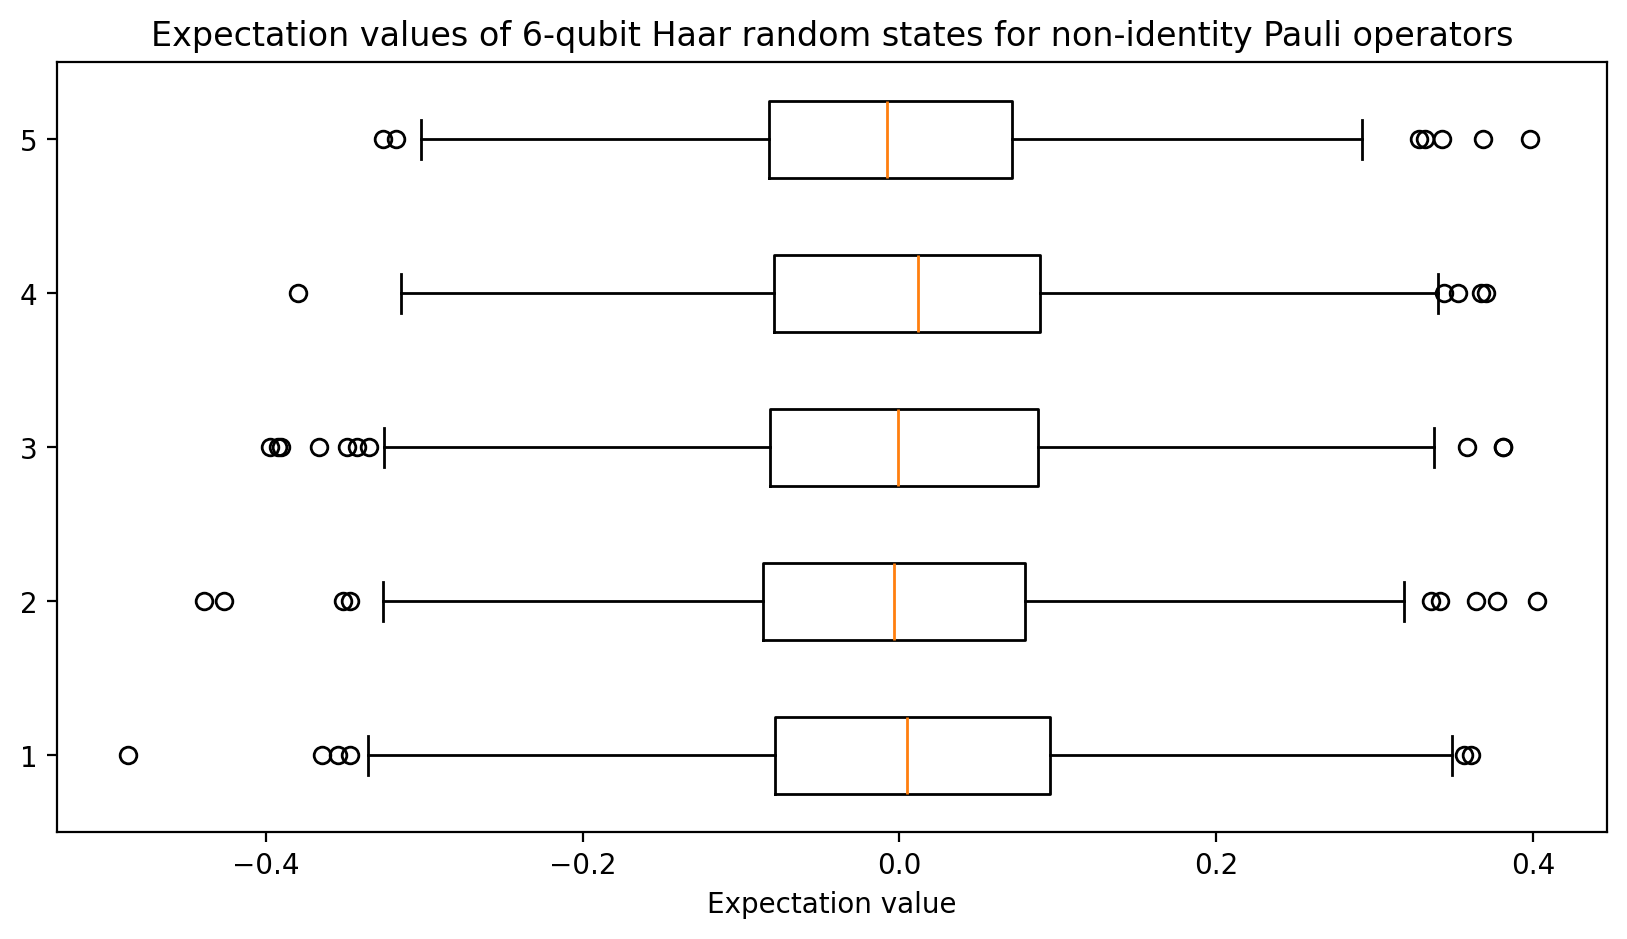

In [94]:
# generate a non-identity Pauli operator
def non_identity_pauli(n_qubits):
    """
    Generate a random non-identity Pauli operator for n_qubits.
    """
    while True:
        pauli_str = ''.join(np.random.choice(['I', 'X', 'Y', 'Z'], size=n_qubits))
        if pauli_str != 'I' * n_qubits:  # Ensure it's not the identity
            return Pauli(pauli_str) 

n = 6
rand_pauli = non_identity_pauli(n)

n_states = 1000
haar_states = [random_statevector(2**n) for _ in range(n_states)]
# Verify 2-design property using Haar random states
expvals = [[states.expectation_value(non_identity_pauli(n)) for states in haar_states] for _ in range(5)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(expvals, vert=False)
ax.set_title(f"Expectation values of {n}-qubit Haar random states for non-identity Pauli operators")
ax.set_xlabel("Expectation value")

Text(0.5, 0, 'Expectation value')

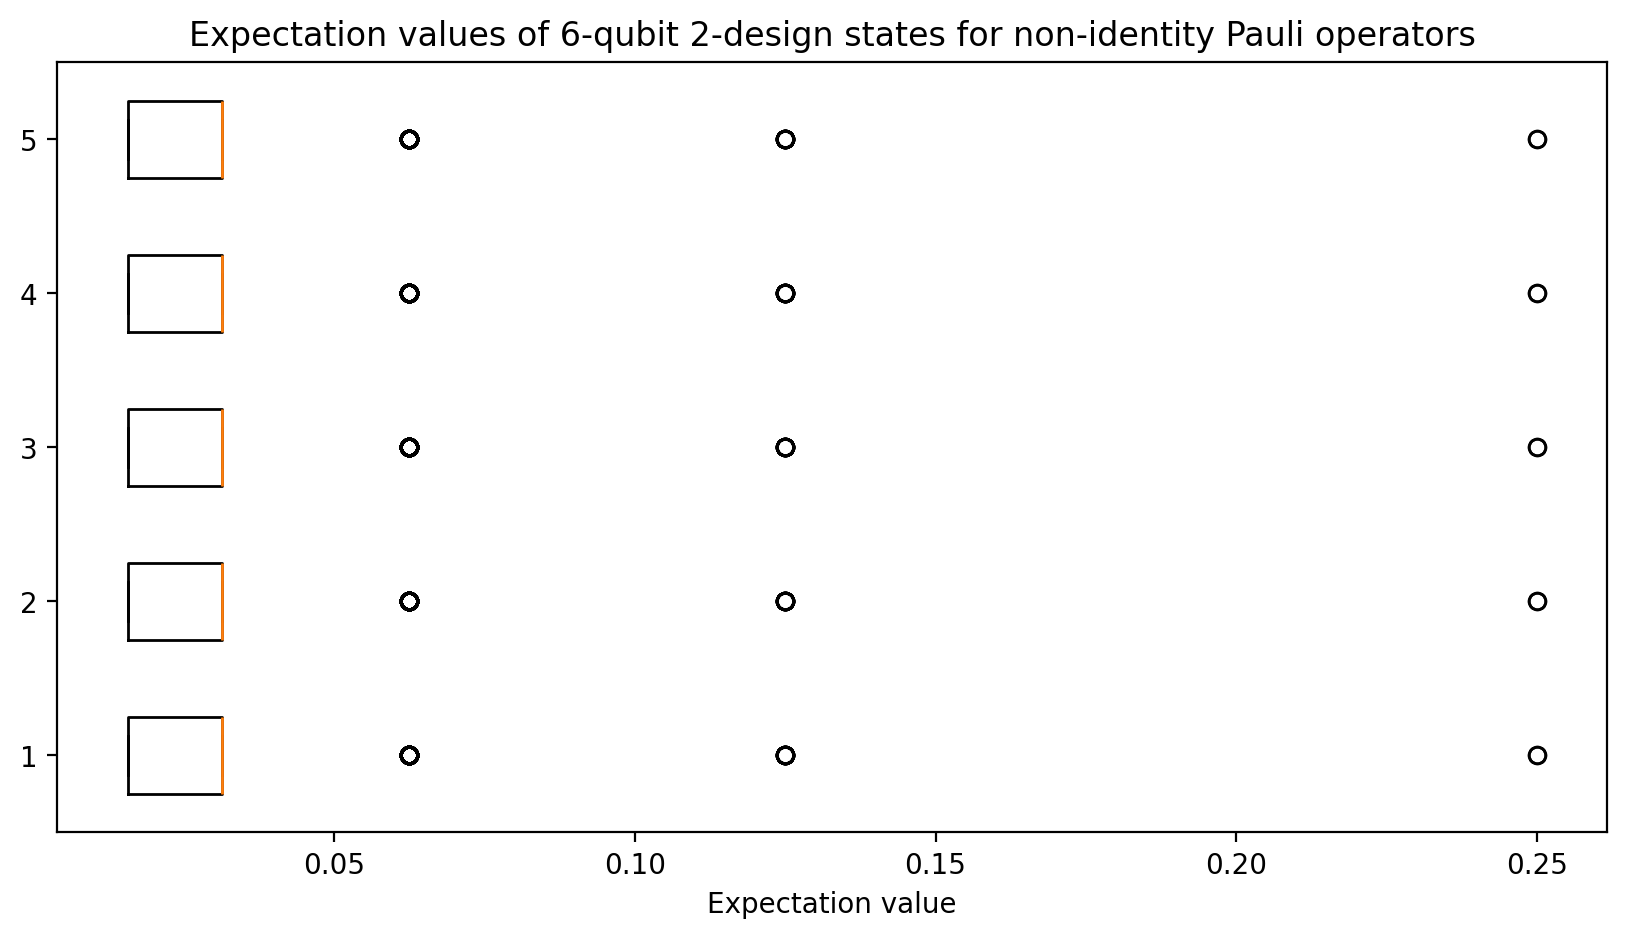

In [87]:
n_states = 1000
design2_states = generate_clifford_2_design(n, n_states)
expvals = [[np.real(np.sum(np.abs(state.data)**4)) for state in design2_states] for _ in range(5)]
# expvals = [[purity(states) for states in design2_states] for _ in range(10)]
# expvals = [[states.expectation_value(non_identity_pauli(n)) for states in design2_states] for _ in range(10)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.boxplot(expvals, vert=False)
ax.set_title(f"Expectation values of {n}-qubit 2-design states for non-identity Pauli operators")
ax.set_xlabel("Expectation value")

Generating Clifford-based 2-design...

Generating random circuit-based approximate 2-design...

Verifying Clifford 2-design:
Expected purity for 2-design: 0.222222
Measured average purity: 0.124250 ± 0.120543
Relative error: 44.09%

Verifying random circuit 2-design:
Expected purity for 2-design: 0.222222
Measured average purity: 0.123272 ± 0.112030
Relative error: 44.53%


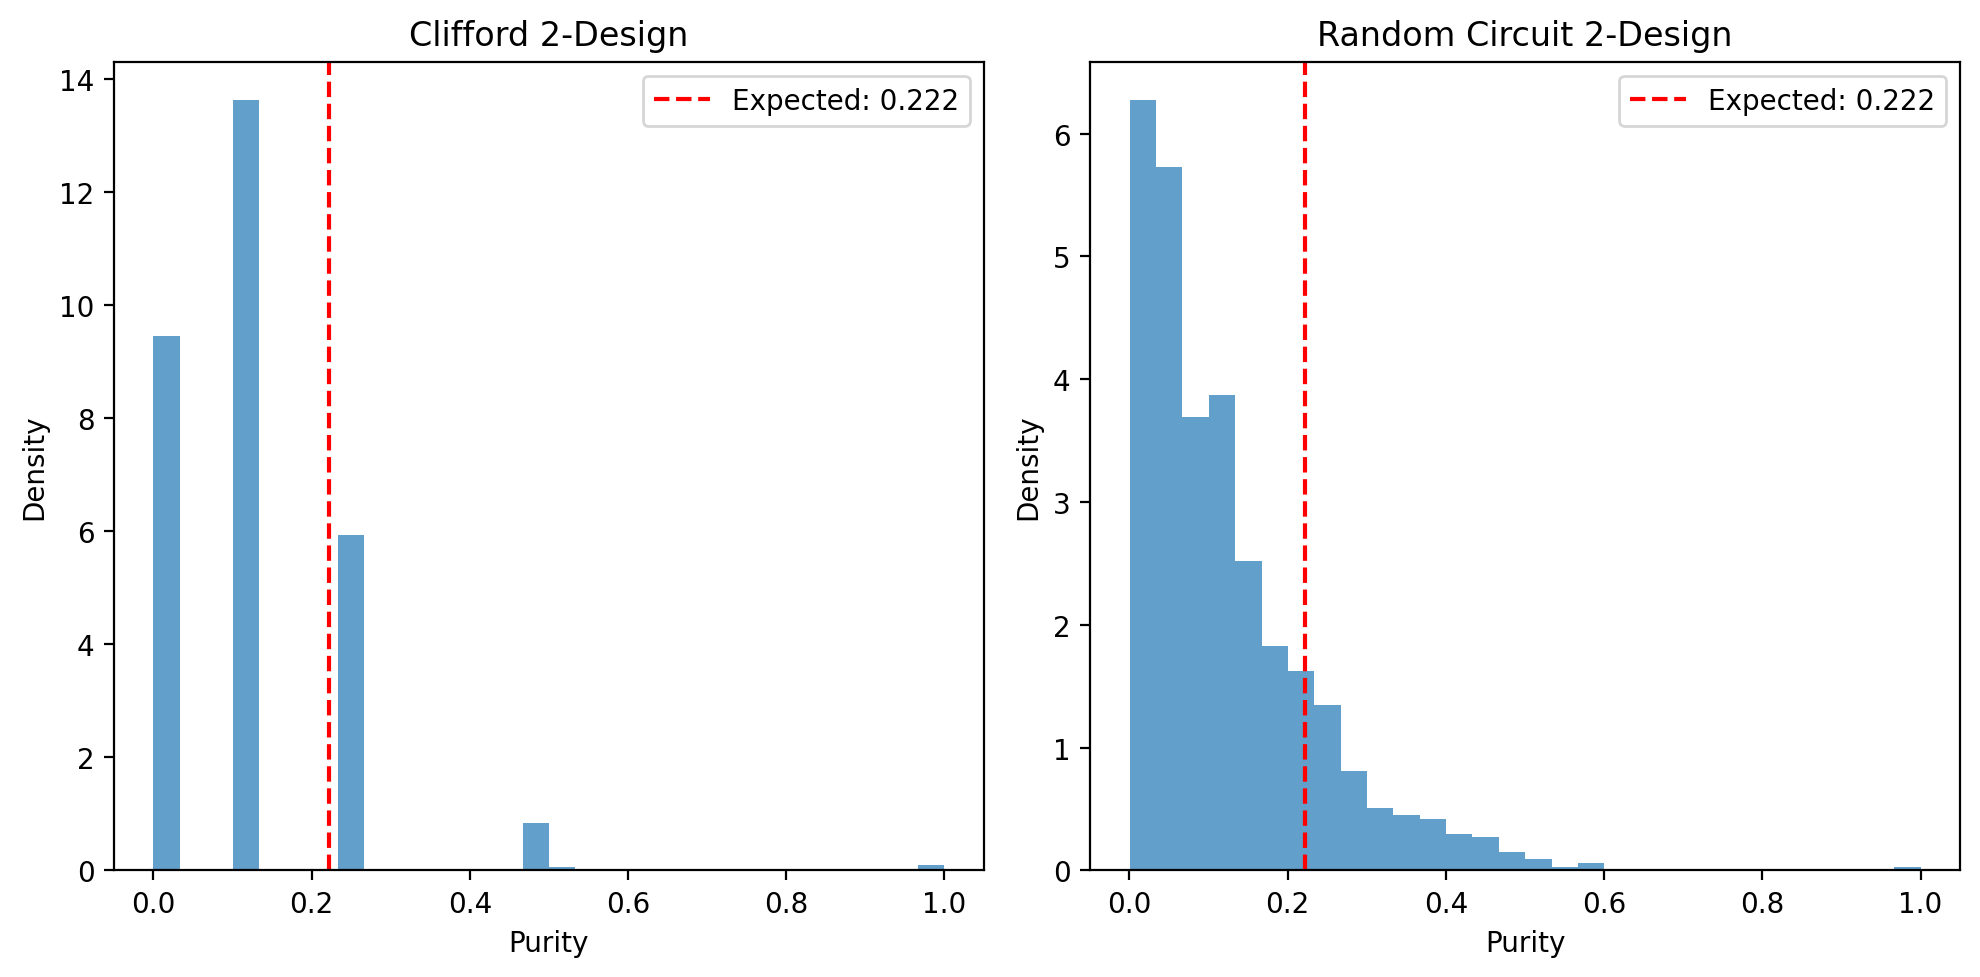


Example state from 2-design:
State vector shape: (8,)
First few amplitudes: [0.35355339+4.76210391e-18j 0.35355339+4.76210391e-18j
 0.35355339-4.76210391e-18j 0.35355339-4.76210391e-18j]


In [4]:
# Example usage
n_qubits = 3
n_states = 500

# Method 1: Clifford-based 2-design
print("Generating Clifford-based 2-design...")
clifford_states = generate_clifford_2_design(n_qubits, n_states)

# Method 2: Random circuit approximation
print("\nGenerating random circuit-based approximate 2-design...")
circuit_states = generate_random_circuit_2_design(n_qubits, n_states)

# Verify the 2-design property
print("\nVerifying Clifford 2-design:")
cliff_purities = verify_2_design_property(clifford_states)

print("\nVerifying random circuit 2-design:")
circ_purities = verify_2_design_property(circuit_states)

# Visualize the distribution
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(cliff_purities, bins=30, alpha=0.7, density=True)
plt.axvline(2/(2**n_qubits + 1), color='r', linestyle='--', 
            label=f'Expected: {2/(2**n_qubits + 1):.3f}')
plt.xlabel('Purity')
plt.ylabel('Density')
plt.title('Clifford 2-Design')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(circ_purities, bins=30, alpha=0.7, density=True)
plt.axvline(2/(2**n_qubits + 1), color='r', linestyle='--',
            label=f'Expected: {2/(2**n_qubits + 1):.3f}')
plt.xlabel('Purity')
plt.ylabel('Density')
plt.title('Random Circuit 2-Design')
plt.legend()

plt.tight_layout()
plt.show()

# Generate a specific state from the 2-design for further use
example_state = clifford_states[0]
print(f"\nExample state from 2-design:")
print(f"State vector shape: {example_state.data.shape}")
print(f"First few amplitudes: {example_state.data[:4]}")

In [ ]:

def verify_2_design_pauli_moments(states, n_qubits, max_weight=None):
    """
    Verify 2-design property by comparing Pauli expectation values with Haar random states.
    
    For a true 2-design, the first and second moments of Pauli expectation values
    should match those of Haar random states.
    
    Args:
        states: List of Statevector objects from 2-design
        n_qubits: Number of qubits
        max_weight: Maximum Pauli weight to test (default: all weights)
    """
    if max_weight is None:
        max_weight = n_qubits
    
    # Generate all Pauli operators up to max_weight
    pauli_strings = []
    pauli_ops = []
    
    for weight in range(1, min(max_weight + 1, n_qubits + 1)):
        # Generate all Pauli strings of given weight
        for positions in product(range(n_qubits), repeat=weight):
            if len(set(positions)) == weight:  # No repeated positions
                for pauli_chars in product(['X', 'Y', 'Z'], repeat=weight):
                    pauli_str = ['I'] * n_qubits
                    for pos, char in zip(positions, pauli_chars):
                        pauli_str[pos] = char
                    pauli_string = ''.join(pauli_str)
                    pauli_strings.append(pauli_string)
                    pauli_ops.append(Pauli(pauli_string))
    
    # Limit to reasonable number of Pauli operators for testing
    if len(pauli_ops) > 100:
        indices = np.random.choice(len(pauli_ops), 100, replace=False)
        pauli_ops = [pauli_ops[i] for i in indices]
        pauli_strings = [pauli_strings[i] for i in indices]
    
    print(f"Testing {len(pauli_ops)} Pauli operators")
    
    # Compute expectation values for 2-design states
    design_expectations = []
    for pauli_op in pauli_ops:
        expectations = []
        for state in states:
            exp_val = state.expectation_value(pauli_op)
            expectations.append(exp_val)
        design_expectations.append(expectations)
    
    # Generate Haar random states for comparison
    n_haar_states = len(states)
    haar_states = [random_statevector(2**n_qubits) for _ in range(n_haar_states)]
    
    # Compute expectation values for Haar random states
    haar_expectations = []
    for pauli_op in pauli_ops:
        expectations = []
        for state in haar_states:
            exp_val = state.expectation_value(pauli_op)
            expectations.append(exp_val)
        haar_expectations.append(expectations)
    
    # Compare first and second moments
    print("\nComparing moments of Pauli expectation values:")
    print("="*60)
    print(f"{'Pauli':<12} {'Design μ':<12} {'Haar μ':<12} {'Design σ²':<12} {'Haar σ²':<12}")
    print("-"*60)
    
    first_moment_errors = []
    second_moment_errors = []
    
    for i, pauli_str in enumerate(pauli_strings[:10]):  # Show first 10 for brevity
        design_exp = np.array(design_expectations[i])
        haar_exp = np.array(haar_expectations[i])
        
        # First moment (mean)
        design_mean = np.mean(design_exp)
        haar_mean = np.mean(haar_exp)
        
        # Second moment (variance)
        design_var = np.var(design_exp)
        haar_var = np.var(haar_exp)
        
        first_moment_errors.append(abs(design_mean - haar_mean))
        second_moment_errors.append(abs(design_var - haar_var))
        
        print(f"{pauli_str:<12} {design_mean:>11.6f} {haar_mean:>11.6f} {design_var:>11.6f} {haar_var:>11.6f}")
    
    # Overall statistics
    avg_first_error = np.mean(first_moment_errors)
    avg_second_error = np.mean(second_moment_errors)
    
    print("-"*60)
    print(f"Average first moment error:  {avg_first_error:.6f}")
    print(f"Average second moment error: {avg_second_error:.6f}")
    
    # Statistical test: compare distributions
    from scipy import stats
    
    print("\nStatistical comparison (Kolmogorov-Smirnov test):")
    print("="*50)
    
    significant_differences = 0
    for i, pauli_str in enumerate(pauli_strings[:10]):
        design_exp = np.real(design_expectations[i])  # Take real part
        haar_exp = np.real(haar_expectations[i])
        
        # KS test
        ks_stat, p_value = stats.ks_2samp(design_exp, haar_exp)
        is_significant = p_value < 0.05
        
        if is_significant:
            significant_differences += 1
            
        print(f"{pauli_str:<12} KS={ks_stat:.4f}, p={p_value:.4f} {'*' if is_significant else ''}")
    
    print(f"\nSignificant differences: {significant_differences}/{len(pauli_strings[:10])}")
    
    if significant_differences <= 1:  # Allow for some statistical fluctuation
        print("✓ 2-design property verified: Pauli moments match Haar random")
    else:
        print("✗ 2-design property questionable: Too many significant differences")
    
    return {
        'first_moment_errors': first_moment_errors,
        'second_moment_errors': second_moment_errors,
        'design_expectations': design_expectations,
        'haar_expectations': haar_expectations,
        'pauli_strings': pauli_strings
    }

# Test the 2-design verification
print("Verifying 2-design property using Pauli expectation values...")
results = verify_2_design_pauli_moments(clifford_states[:100], n_qubits, max_weight=2)

Verifying 2-design property using Pauli expectation values...


NameError: name 'clifford_states' is not defined

In [6]:
# Improved 2-design verification with better statistical analysis
def verify_2_design_improved(states, n_qubits, n_test_states=None, significance_level=0.01):
    """
    Improved 2-design verification focusing on theoretical predictions.
    
    For a 2-design, the key theoretical results are:
    1. First moments: E[⟨ψ|P|ψ⟩] = 0 for all non-identity Pauli P
    2. Second moments: E[|⟨ψ|P|ψ⟩|²] = 1 for all Pauli P
    """
    if n_test_states is None:
        n_test_states = min(len(states), 200)
    
    # Use subset of states for faster computation
    test_states = states[:n_test_states]
    
    # Generate representative Pauli operators
    pauli_ops = []
    pauli_labels = []
    
    # Single-qubit Paulis
    for i in range(n_qubits):
        for pauli_char in ['X', 'Y', 'Z']:
            pauli_str = ['I'] * n_qubits
            pauli_str[i] = pauli_char
            pauli_label = ''.join(pauli_str)
            pauli_ops.append(Pauli(pauli_label))
            pauli_labels.append(pauli_label)
    
    # Two-qubit Paulis (sample)
    if n_qubits >= 2:
        for i in range(min(3, n_qubits-1)):  # Limit to avoid too many operators
            for j in range(i+1, min(i+3, n_qubits)):
                for p1, p2 in [('X', 'X'), ('Y', 'Y'), ('Z', 'Z'), ('X', 'Z')]:
                    pauli_str = ['I'] * n_qubits
                    pauli_str[i] = p1
                    pauli_str[j] = p2
                    pauli_label = ''.join(pauli_str)
                    pauli_ops.append(Pauli(pauli_label))
                    pauli_labels.append(pauli_label)
    
    print(f"Testing {len(pauli_ops)} Pauli operators with {n_test_states} states")
    print(f"Significance level: {significance_level}")
    
    # Compute expectation values
    results = []
    
    for i, (pauli_op, label) in enumerate(zip(pauli_ops, pauli_labels)):
        expectations = []
        for state in test_states:
            exp_val = state.expectation_value(pauli_op)
            expectations.append(exp_val)
        
        exp_array = np.array(expectations)
        
        # First moment (should be ~0 for non-identity Pauli)
        first_moment = np.mean(exp_array)
        first_moment_std = np.std(exp_array) / np.sqrt(len(exp_array))
        
        # Second moment (should be ~1 for all Pauli)
        second_moment = np.mean(np.abs(exp_array)**2)
        second_moment_std = np.std(np.abs(exp_array)**2) / np.sqrt(len(exp_array))
        
        # Theoretical predictions
        expected_first = 0.0  # For non-identity Pauli
        expected_second = 1.0  # For all Pauli
        
        # Statistical tests
        first_z_score = abs(first_moment - expected_first) / first_moment_std if first_moment_std > 0 else 0
        second_z_score = abs(second_moment - expected_second) / second_moment_std if second_moment_std > 0 else 0
        
        # Convert to p-values (two-tailed test)
        from scipy.stats import norm
        first_p_value = 2 * (1 - norm.cdf(first_z_score))
        second_p_value = 2 * (1 - norm.cdf(second_z_score))
        
        results.append({
            'pauli': label,
            'first_moment': first_moment,
            'first_std': first_moment_std,
            'first_p': first_p_value,
            'second_moment': second_moment,
            'second_std': second_moment_std,
            'second_p': second_p_value,
            'first_significant': first_p_value < significance_level,
            'second_significant': second_p_value < significance_level
        })
    
    # Summary statistics
    print("\nDetailed Results:")
    print("="*85)
    print(f"{'Pauli':<8} {'1st moment':<12} {'±':<8} {'p-val':<8} {'2nd moment':<12} {'±':<8} {'p-val':<8} {'Status'}")
    print("-"*85)
    
    first_failures = 0
    second_failures = 0
    
    for r in results:
        first_status = "FAIL" if r['first_significant'] else "PASS"
        second_status = "FAIL" if r['second_significant'] else "PASS"
        overall_status = "FAIL" if (r['first_significant'] or r['second_significant']) else "PASS"
        
        if r['first_significant']:
            first_failures += 1
        if r['second_significant']:
            second_failures += 1
        
        print(f"{r['pauli']:<8} {r['first_moment']:>11.6f} {r['first_std']:>7.4f} {r['first_p']:>7.4f} "
              f"{r['second_moment']:>11.6f} {r['second_std']:>7.4f} {r['second_p']:>7.4f} {overall_status}")
    
    print("-"*85)
    print(f"First moment failures:  {first_failures}/{len(results)}")
    print(f"Second moment failures: {second_failures}/{len(results)}")
    
    # Expected number of false positives
    expected_false_positives = len(results) * significance_level
    total_failures = first_failures + second_failures
    
    print(f"\nExpected false positives: {expected_false_positives:.1f}")
    print(f"Total failures observed: {total_failures}")
    
    if total_failures <= expected_false_positives * 2:  # Allow some margin
        print("✓ 2-design property VERIFIED: Failure rate consistent with statistical noise")
        design_quality = "GOOD"
    elif total_failures <= expected_false_positives * 4:
        print("~ 2-design property MARGINAL: Some deviations observed")
        design_quality = "MARGINAL"
    else:
        print("✗ 2-design property POOR: Too many significant deviations")
        design_quality = "POOR"
    
    return results, design_quality

# Test with improved analysis
print("Improved 2-design verification:")
results_improved, quality = verify_2_design_improved(clifford_states, n_qubits, n_test_states=300)

print(f"\nTesting random circuit 2-design for comparison:")
circuit_results, circuit_quality = verify_2_design_improved(circuit_states, n_qubits, n_test_states=300)

Improved 2-design verification:


NameError: name 'clifford_states' is not defined